# Satellite Fault Detection — Data Exploration

This notebook explores the synthetic satellite telemetry dataset generated by `src/data_generator.py`.

**Goals:**
- Understand the shape and distribution of each sensor
- Visualize nominal vs fault samples
- Verify class balance before training

In [2]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load
from data_generator import config, normal_ranges, fault_signatures

df = load(source = "synthetic")
df.head()

Loaded synthetic data
Shape   : (1000, 7)
Columns : ['battery_voltage', 'solar_current', 'panel_temp', 'onboard_temp', 'attitude_error', 'reaction_wheel_rpm', 'label']
Faults  : 124
Nominal : 876


,battery_voltage,solar_current,panel_temp,onboard_temp,attitude_error,reaction_wheel_rpm,label
0,25.445854,1.921408,8.326763,28.433852,0.300639,2574.605562,0
1,27.826528,2.574280,7.254491,30.933718,0.308694,2893.680380,0
2,26.942523,3.217188,53.468568,20.015243,0.301611,4418.257454,0
3,26.442526,2.950393,7.493718,27.413894,0.045106,2360.010365,0
4,24.584530,3.142090,9.077066,26.570436,0.084982,4478.619665,0


## Class Balance

Check how many nominal vs fault samples exist in the dataset.

Nominal samples : 876
Fault samples   : 124
Fault rate      : 12.4%


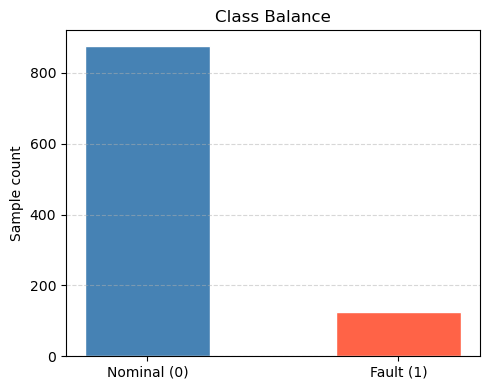

Saved to outputs/plots/class_balance.png


In [5]:
labels      = df["label"].value_counts()
fault_rate  = df["label"].mean() * 100

print(f"Nominal samples : {labels[0]}")
print(f"Fault samples   : {labels[1]}")
print(f"Fault rate      : {fault_rate:.1f}%")

# bar chart
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Nominal (0)", "Fault (1)"], [labels[0], labels[1]],
       color=["steelblue", "tomato"], edgecolor="white", width=0.5)
ax.set_ylabel("Sample count")
ax.set_title("Class Balance")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../outputs/plots/class_balance.png", dpi=100)
plt.show()

print("Saved to outputs/plots/class_balance.png")

## Sensor Distributions — Nominal vs Fault

Each sensor is plotted as a histogram, split by label.
Blue = nominal, Red = fault. The separation between them
shows why the SLP can classify this data linearly.

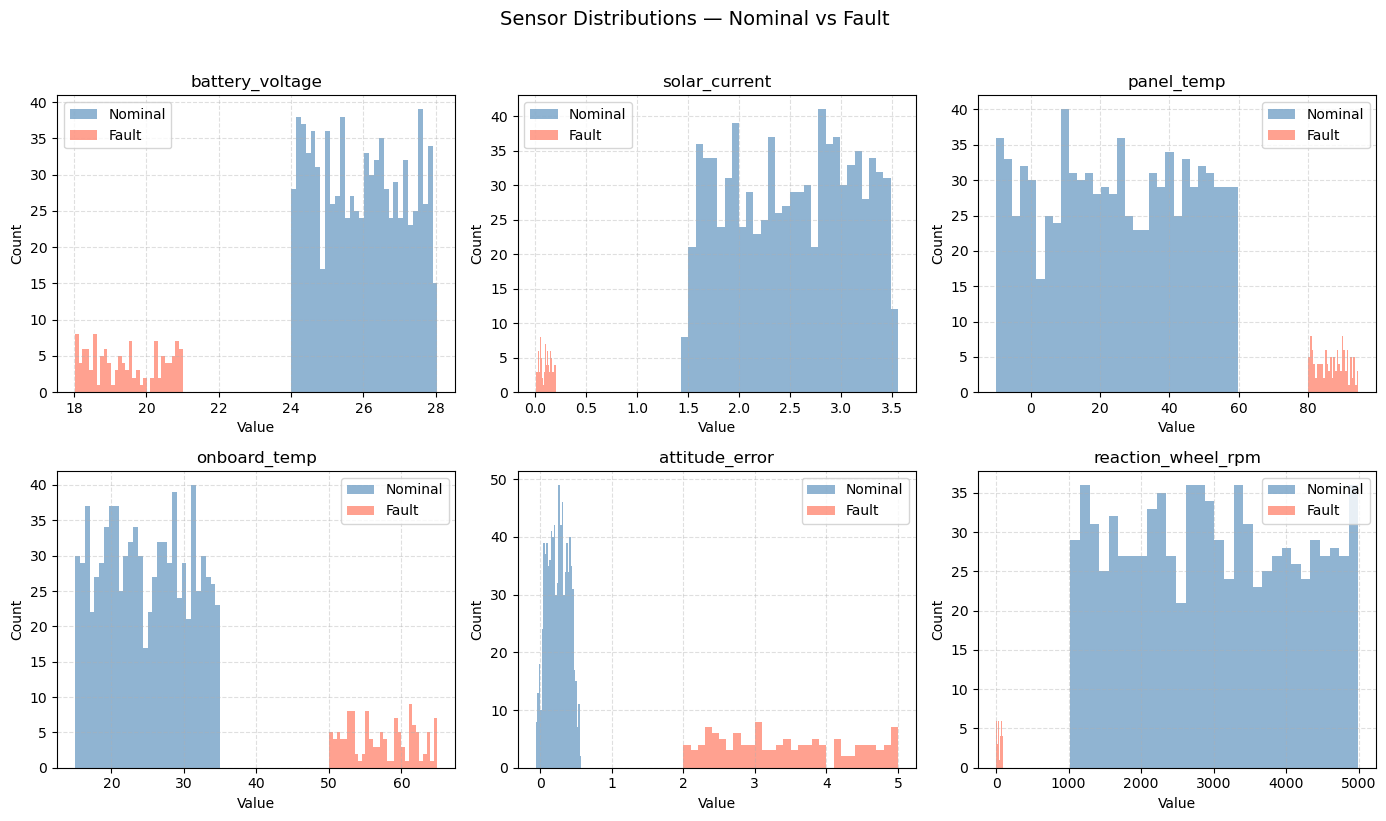

Saved to outputs/plots/sensor_distributions.png


In [9]:
sensors = [col for col in df.columns if col != "label"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    nominal = df[df["label"] == 0][sensor]
    fault   = df[df["label"] == 1][sensor]

    axes[i].hist(nominal, bins=30, alpha=0.6, color="steelblue", label="Nominal")
    axes[i].hist(fault,   bins=30, alpha=0.6, color="tomato",    label="Fault")
    axes[i].set_title(sensor)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].legend()
    axes[i].grid(linestyle="--", alpha=0.4)

plt.suptitle("Sensor Distributions — Nominal vs Fault", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/plots/sensor_distributions.png", dpi=100, bbox_inches="tight")
plt.show()

print("Saved to outputs/plots/sensor_distributions.png")

## Fault Events Over Time 

Faults are injected as consecutive windows, not random individual rows.
This simulates realistic anomaly events on a satellite.

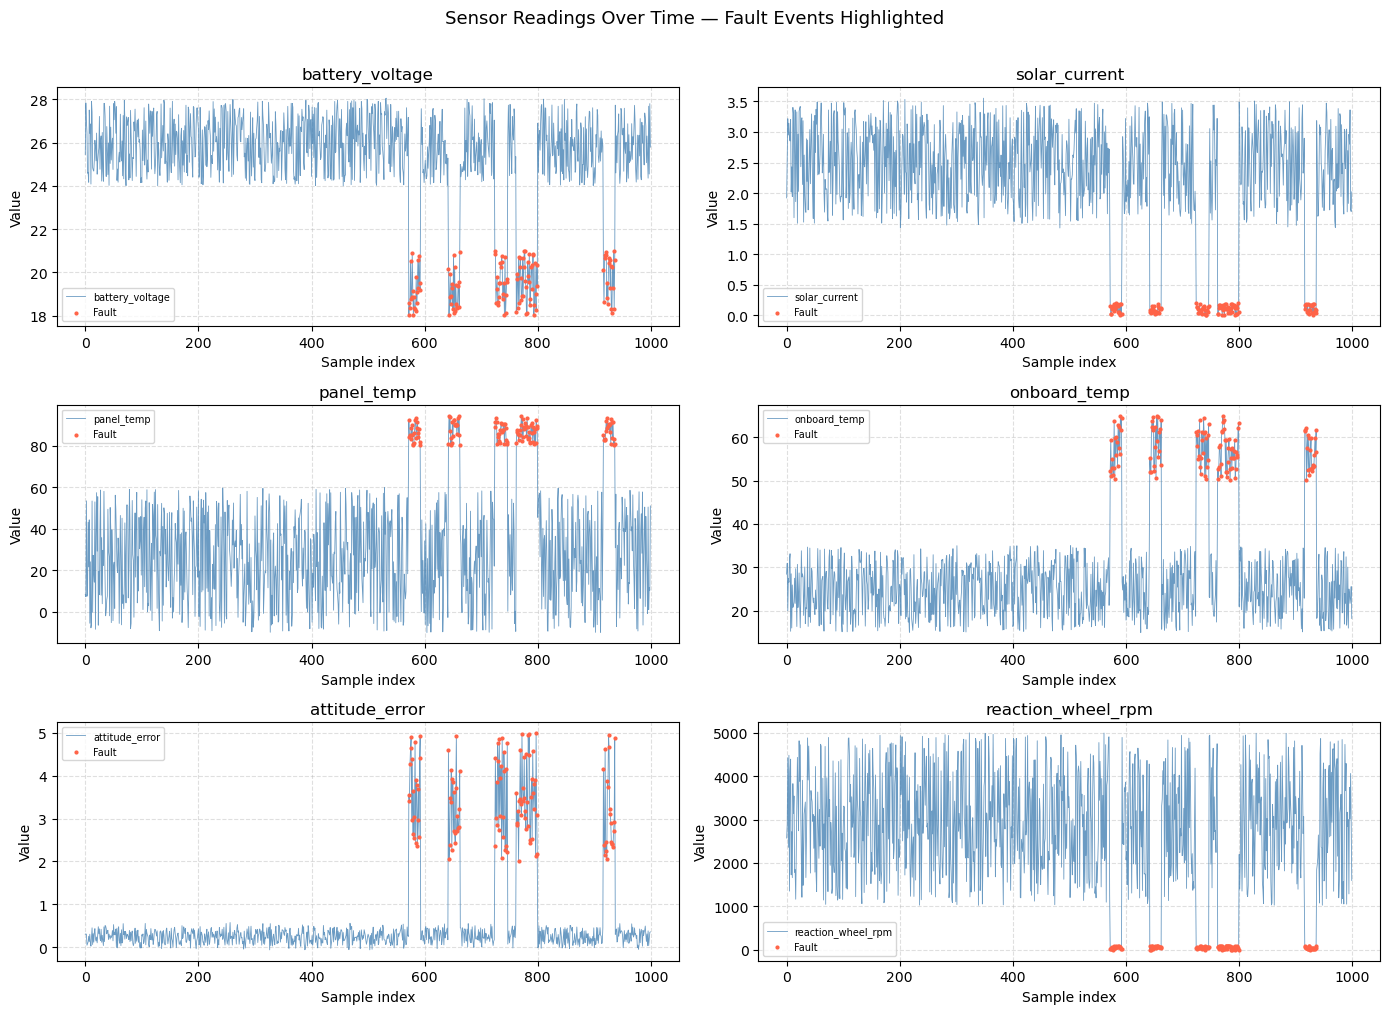

Saved to outputs/plots/fault_events.png


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    axes[i].plot(df.index, df[sensor],
                 color="steelblue", linewidth=0.6, alpha=0.8, label=sensor)

    # highlight fault windows in red
    fault_idx = df[df["label"] == 1].index
    axes[i].scatter(fault_idx, df.loc[fault_idx, sensor],
                    color="tomato", s=4, zorder=5, label="Fault")

    axes[i].set_title(sensor)
    axes[i].set_xlabel("Sample index")
    axes[i].set_ylabel("Value")
    axes[i].legend(fontsize=7)
    axes[i].grid(linestyle="--", alpha=0.4)

plt.suptitle("Sensor Readings Over Time — Fault Events Highlighted", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plots/fault_events.png", dpi=100, bbox_inches="tight")
plt.show()

print("Saved to outputs/plots/fault_events.png")

## Key Observations

- **Class imbalance:** 12.4% fault rate — realistic for satellite operations
- **Clear separation:** Fault signatures occupy completely different value ranges 
  from nominal readings across all 6 sensors
- **Simultaneous faults:** All sensors show anomalies at the same time indices,
  reflecting real multi-subsystem fault events
- **Conclusion:** Data is linearly separable — a Single Layer Perceptron is 
  sufficient for this synthetic dataset. Real telemetry will present overlapping 
  classes, which is addressed in Phase 2 with the ESA OPSSAT-AD dataset.